TASK 3 - Credit Risk Analysis

Load and explore the data

In [2]:
import pandas as pd

# Load sample loan data
df = pd.read_csv("Task 3 and 4_Loan_Data.csv")  # Replace with your path

# Quick look
print(df.head())
print(df.info())
print(df.describe())

# Check target variable distribution
print(df['default'].value_counts(normalize=True))

   customer_id  credit_lines_outstanding  loan_amt_outstanding  \
0      8153374                         0           5221.545193   
1      7442532                         5           1958.928726   
2      2256073                         0           3363.009259   
3      4885975                         0           4766.648001   
4      4700614                         1           1345.827718   

   total_debt_outstanding       income  years_employed  fico_score  default  
0             3915.471226  78039.38546               5         605        0  
1             8228.752520  26648.43525               2         572        1  
2             2027.830850  65866.71246               4         602        0  
3             2501.730397  74356.88347               5         612        0  
4             1768.826187  23448.32631               6         631        0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 

Feature Engineering

In [3]:
# 1. Clean column names
df.columns = df.columns.str.strip().str.lower()
print("Columns:", df.columns.tolist())

# 2. Validate target column
if 'default' not in df.columns:
    raise ValueError("Target column 'default' not found")

# 3. Use correct loan-related columns from YOUR dataset
loan_col = 'loan_amt_outstanding'
debt_col = 'total_debt_outstanding'

# 4. Create important financial ratios

# Debt-to-Income Ratio (VERY important in credit risk)
df['debt_to_income'] = df[debt_col] / df['income']

# Loan-to-Income Ratio
df['loan_to_income'] = df[loan_col] / df['income']

# Credit stress indicator
df['credit_utilization'] = df['credit_lines_outstanding'] / (df['income'] + 1)

# 5. Handle missing values
df = df.fillna(df.median(numeric_only=True))

# 6. Drop unnecessary columns (IDs should not be used for prediction)
df = df.drop(columns=['customer_id'])

# 7. No categorical columns in your dataset → skip encoding
print("Final columns after feature engineering:")
print(df.columns.tolist())

Columns: ['customer_id', 'credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default']
Final columns after feature engineering:
['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'default', 'debt_to_income', 'loan_to_income', 'credit_utilization']


Train model

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

# Split features and target
X = df.drop(columns=['default'])
y = df['default']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Evaluate
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

print("\nClassification Report:")
print(classification_report(y_test, model.predict(X_test)))

AUC Score: 0.9999913027747628

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       1.00      0.98      0.99       348

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



Probability of default function

In [5]:
def predict_pd(input_data):
    input_df = pd.DataFrame([input_data])

    # Match training columns
    input_df = input_df.reindex(columns=X.columns, fill_value=0)

    pd_value = model.predict_proba(input_df)[:, 1][0]
    return pd_value

Expected Loss Function

In [6]:
def expected_loss(loan_amount, input_data):
    pd_value = predict_pd(input_data)

    recovery_rate = 0.10
    lgd = 1 - recovery_rate

    return loan_amount * pd_value * lgd

Test the Model

In [7]:
sample_borrower = {
    col: 0 for col in X.columns
}

# Example realistic inputs (modify based on your dataset)
if 'income' in sample_borrower:
    sample_borrower['income'] = 50000

if loan_col in sample_borrower:
    sample_borrower[loan_col] = 20000

if 'debt_to_income' in sample_borrower:
    sample_borrower['debt_to_income'] = 20000 / 50000

# Predict PD
pd_val = predict_pd(sample_borrower)
print("Predicted PD:", pd_val)

# Expected loss
loss = expected_loss(100000, sample_borrower)
print("Expected Loss:", loss)

Predicted PD: 0.9492612302582215
Expected Loss: 85433.51072323993


Visualization

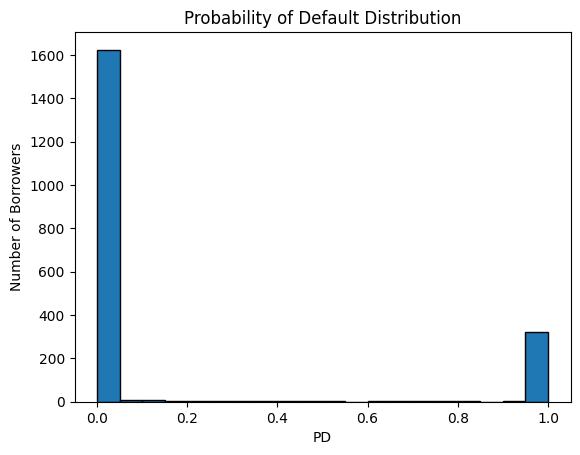

In [8]:
import matplotlib.pyplot as plt

plt.hist(y_prob, bins=20, edgecolor='black')
plt.title("Probability of Default Distribution")
plt.xlabel("PD")
plt.ylabel("Number of Borrowers")
plt.show()

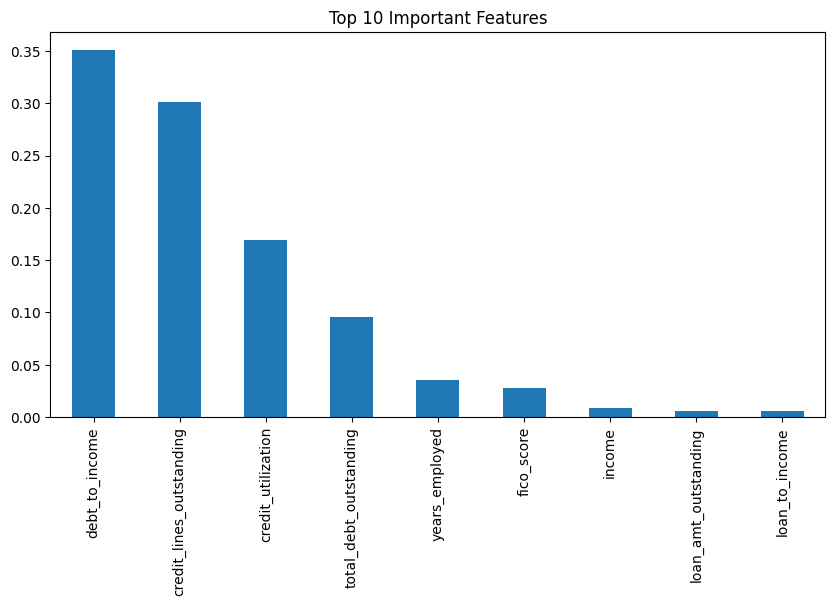

In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

importances.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Important Features")
plt.show()

Company profile presentation

Prepare Data

In [10]:
# Ensure columns are clean
df.columns = df.columns.str.strip().str.lower()

# Keep only required columns
fico_df = df[['fico_score', 'default']].copy()

# Sort by FICO score
fico_df = fico_df.sort_values('fico_score').reset_index(drop=True)

print(fico_df.head())

   fico_score  default
0         408        0
1         409        1
2         418        1
3         425        1
4         438        1


Bucketing

In [11]:
import numpy as np

def create_fico_buckets(df, n_buckets):
    df = df.sort_values('fico_score').reset_index(drop=True)

    # Start with quantile splits
    df['bucket'] = pd.qcut(df['fico_score'], q=n_buckets, labels=False, duplicates='drop')

    return df

# Apply
fico_df = create_fico_buckets(fico_df, n_buckets=5)

# Compute PD per bucket
bucket_summary = fico_df.groupby('bucket').agg(
    min_fico=('fico_score', 'min'),
    max_fico=('fico_score', 'max'),
    count=('default', 'count'),
    defaults=('default', 'sum')
)

bucket_summary['pd'] = bucket_summary['defaults'] / bucket_summary['count']

print(bucket_summary)

        min_fico  max_fico  count  defaults        pd
bucket                                               
0            408       587   2050       817  0.398537
1            588       623   1971       425  0.215627
2            624       653   1989       301  0.151332
3            654       688   1997       200  0.100150
4            689       850   1993       108  0.054190


Create Rating Map

In [12]:
# Sort by PD (low PD = better borrowers)
bucket_summary = bucket_summary.sort_values('pd')

# Assign ratings
bucket_summary['rating'] = range(1, len(bucket_summary) + 1)

print(bucket_summary)

        min_fico  max_fico  count  defaults        pd  rating
bucket                                                       
4            689       850   1993       108  0.054190       1
3            654       688   1997       200  0.100150       2
2            624       653   1989       301  0.151332       3
1            588       623   1971       425  0.215627       4
0            408       587   2050       817  0.398537       5


Function for future Data

In [13]:
def assign_rating(fico_score, bucket_table):
    for _, row in bucket_table.iterrows():
        if row['min_fico'] <= fico_score <= row['max_fico']:
            return row['rating']
    return None

# Example usage
if __name__ == "__main__":
    print(assign_rating(720, bucket_summary))

1.0


Visualization

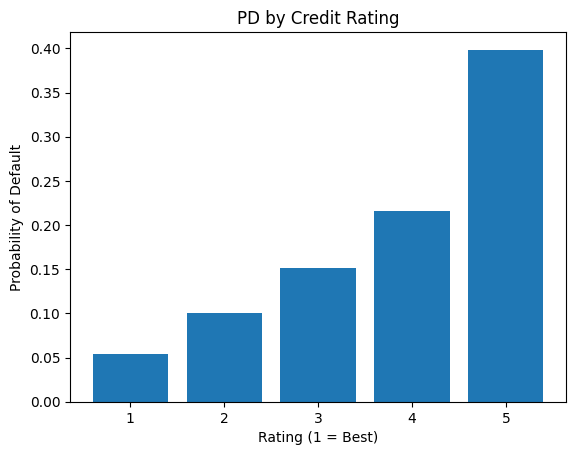

In [14]:
import matplotlib.pyplot as plt

plt.bar(bucket_summary['rating'], bucket_summary['pd'])
plt.title("PD by Credit Rating")
plt.xlabel("Rating (1 = Best)")
plt.ylabel("Probability of Default")
plt.show()